In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dowhy

### What is a DAG?

A **DAG** (Directed Acyclic Graph) is a visual map of your causal assumptions. It shows:

- **Nodes:** Variables ($X$, $Y$, $Z$)
- **Arrows ($\rightarrow$):** Causal direction ($X$ causes $Y$)
- **Acyclic:** No cycles (A can't cause B if B causes A)


> **The Golden Rule:** If you can't draw your causal assumptions, you don't understand your problem. DAGs force you to be explicit about what you believe.

```mermaid
graph LR
    S[Severity] --> P[Takes Pill]
    S --> R[Relief Score]
    P --> R
```

The arrow from Severity to Takes Pill and Severity to Relief creates a back-door path: Takes Pill ← Severity → Relief. This is the confounder!

| Pattern | Structure | Rule |
|---------|-----------|------|
| **Chain** | $A \rightarrow B \rightarrow C$ | ❌ Don't adjust for B |
| **Fork** | $A \leftarrow B \rightarrow C$ | ✅ Adjust for B |
| **Collider** | $A \rightarrow B \leftarrow C$ | ❌ Don't adjust for B |

In [12]:
np.random.seed(42)
n = 1000

# generate the Confounder (Severity of headache)
severity = np.random.normal(5, 1, n)  # Scale 1-10

# severity causes people to TAKE painkillers (X)
# (people with worse headaches are more likely to take the pill)
takes_pill = np.random.binomial(1, 1 / (1 + np.exp(5 - severity)), n)

# severity causes the OUTCOME (headache relief)
# (worse headaches take longer to go away, even with pills)
relief = 5 - 0.5 * severity + 2 * takes_pill + np.random.normal(0, 0.5, n)

df = pd.DataFrame({
    'Took_Pill': takes_pill,
    'Relief_Score': relief,
    'Severity': severity
})

df

,Took_Pill,Relief_Score,Severity
0,1,4.097038,5.496714
1,0,2.193054,4.861736
2,1,4.335743,5.647689
3,1,4.408710,6.523030
4,0,1.679490,4.765847
...,...,...,...
995,0,2.315668,4.718900
996,1,2.999556,6.797687
997,1,3.658556,5.640843
998,0,2.541988,4.428821


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                
────────────(E[Relief_Score|Severity])
d[Took_Pill]                          
Estimand assumption 1, Unconfoundedness: If U→{Took_Pill} and U→Relief_Score then P(Relief_Score|Took_Pill,Severity,U) = P(Relief_Score|Took_Pill,Severity)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                
────────────(E[Relief_Score|Severity])
d[Took_Pill]                          
Estimand assumption 1, Unconfoundedness: If U→{Took_Pill} and U→Relief_Score then P(Relief_Score|Took_Pill,Severity,U) = P(Relief_Score|Took_Pill,Severity)



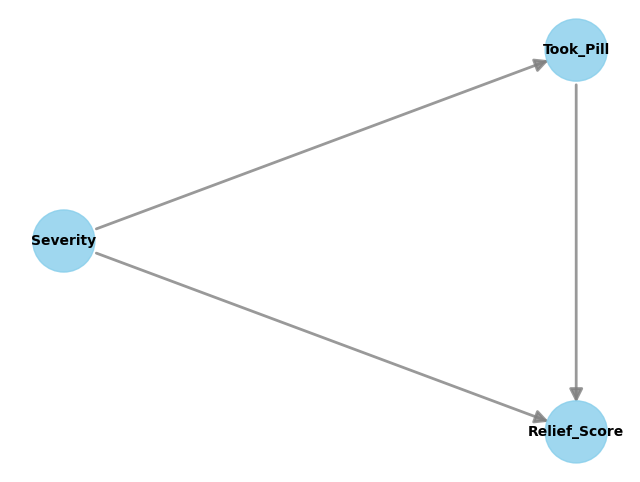

In [13]:
# Define the DAG with explicit variable names
dag_text = """
digraph {
    Severity -> Took_Pill;
    Severity -> Relief_Score;
    Took_Pill -> Relief_Score;
}
"""

# Create causal model
model = CausalModel(
    data=df,
    treatment='Took_Pill',
    outcome='Relief_Score',
    graph=dag_text
)

# Identify the causal effect
identified_estimand = model.identify_effect()
print(identified_estimand)

# View the DAG
model.view_model(file_name='017_dags')